# 12 · Publication Figures and Tables

**What this notebook does:** Re-runs all key analyses and saves final,
publication-ready versions of every figure and table for the report.

**Inputs:** All processed data

**Outputs:** Final figures in `reports/figures/` and `paper_or_report/figures/`
             Final tables in `reports/tables/` and `paper_or_report/tables/`

In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import get_path, BRAND_COLORS, VIZ_PARAMS
from src.data_loader import load_cbn_payments, load_efina_summary, load_competitors
from src.financial_model import project_users, project_revenue, project_income_statement
from src.market_sizing import compute_tam_sam_som
from src.risk_model import build_risk_registry, strategic_opportunities
from src.viz import (apply_project_style, save_figure, plot_inclusion_trend,
                      plot_payment_growth, plot_market_sizing_funnel, plot_risk_matrix)

apply_project_style()

tables_dir   = get_path("reports_tables")
paper_tables = get_path("paper_tables")

df_cbn   = load_cbn_payments()
df_efina = load_efina_summary()
df_comp  = load_competitors()
print("All data loaded for publication output.")

All data loaded for publication output.


  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig01_inclusion_trend.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig01_inclusion_trend.pdf


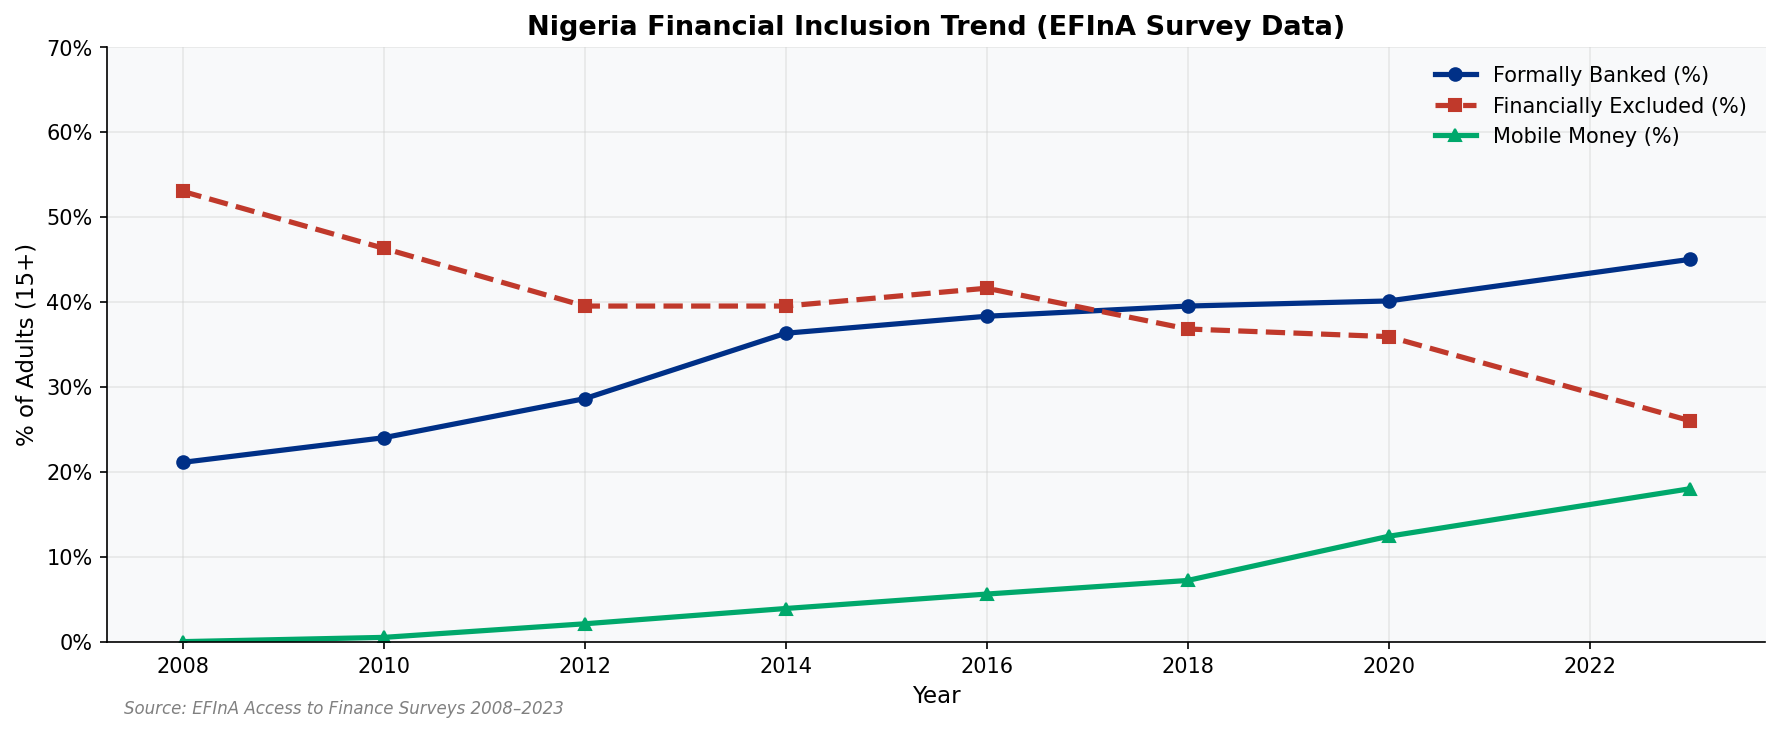

Saved: PUB_fig01_inclusion_trend


In [3]:
# FIGURE 1 — Financial Inclusion Trend (publication quality)
fig, ax = plt.subplots(figsize=(12, 5))
plot_inclusion_trend(df_efina, ax)
plt.tight_layout()
save_figure(fig, "PUB_fig01_inclusion_trend.png")
plt.show()
print("Saved: PUB_fig01_inclusion_trend")

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig02_nip_growth.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig02_nip_growth.pdf


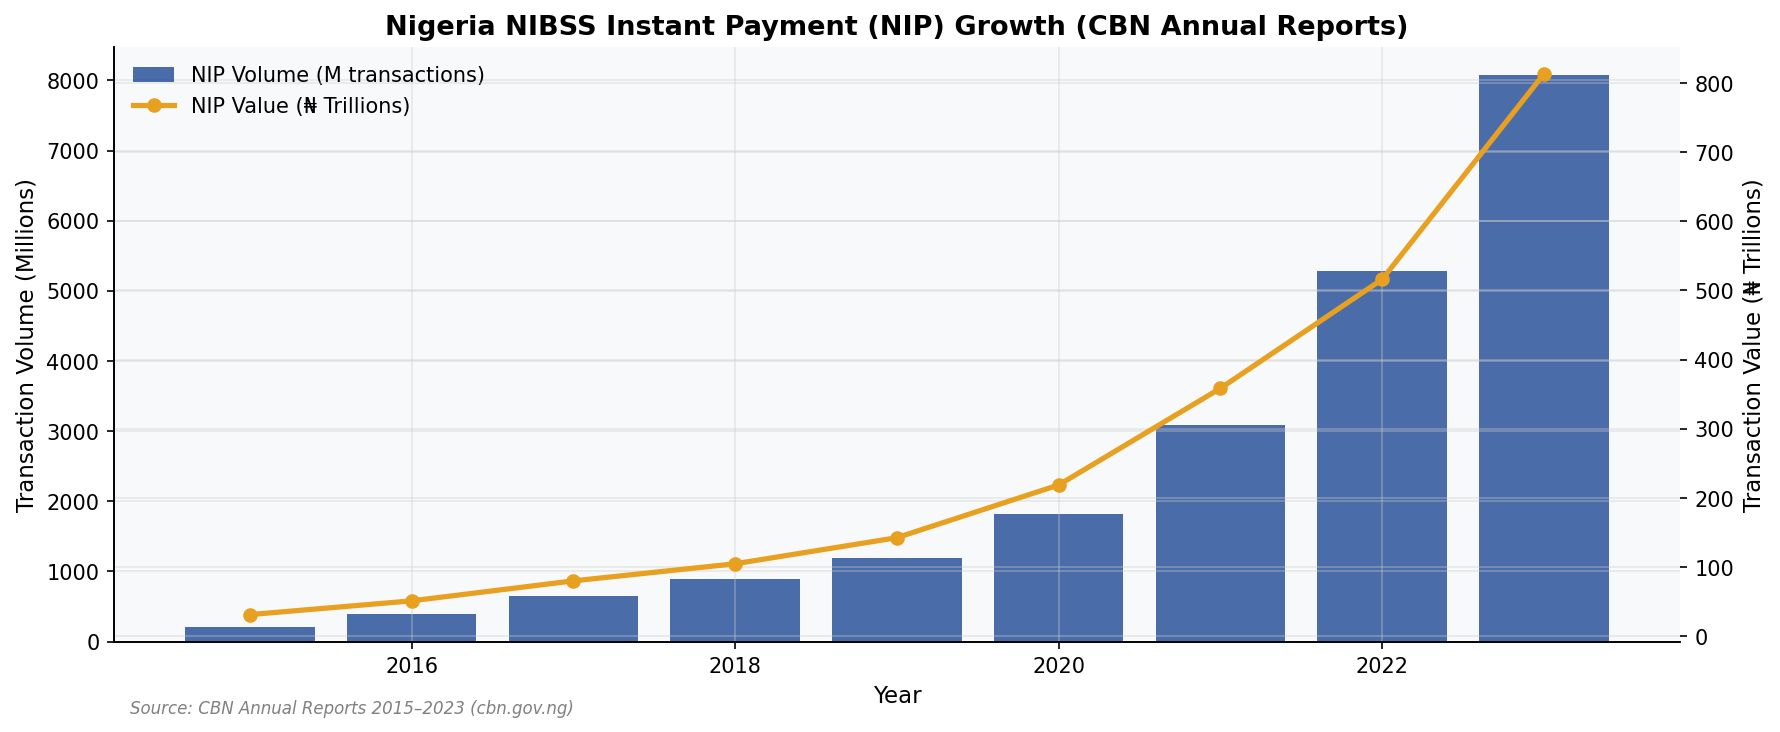

Saved: PUB_fig02_nip_growth


In [4]:
# FIGURE 2 — NIP Payment Growth
fig, ax = plt.subplots(figsize=(12, 5))
plot_payment_growth(df_cbn, ax)
plt.tight_layout()
save_figure(fig, "PUB_fig02_nip_growth.png")
plt.show()
print("Saved: PUB_fig02_nip_growth")

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig03_market_funnel.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig03_market_funnel.pdf


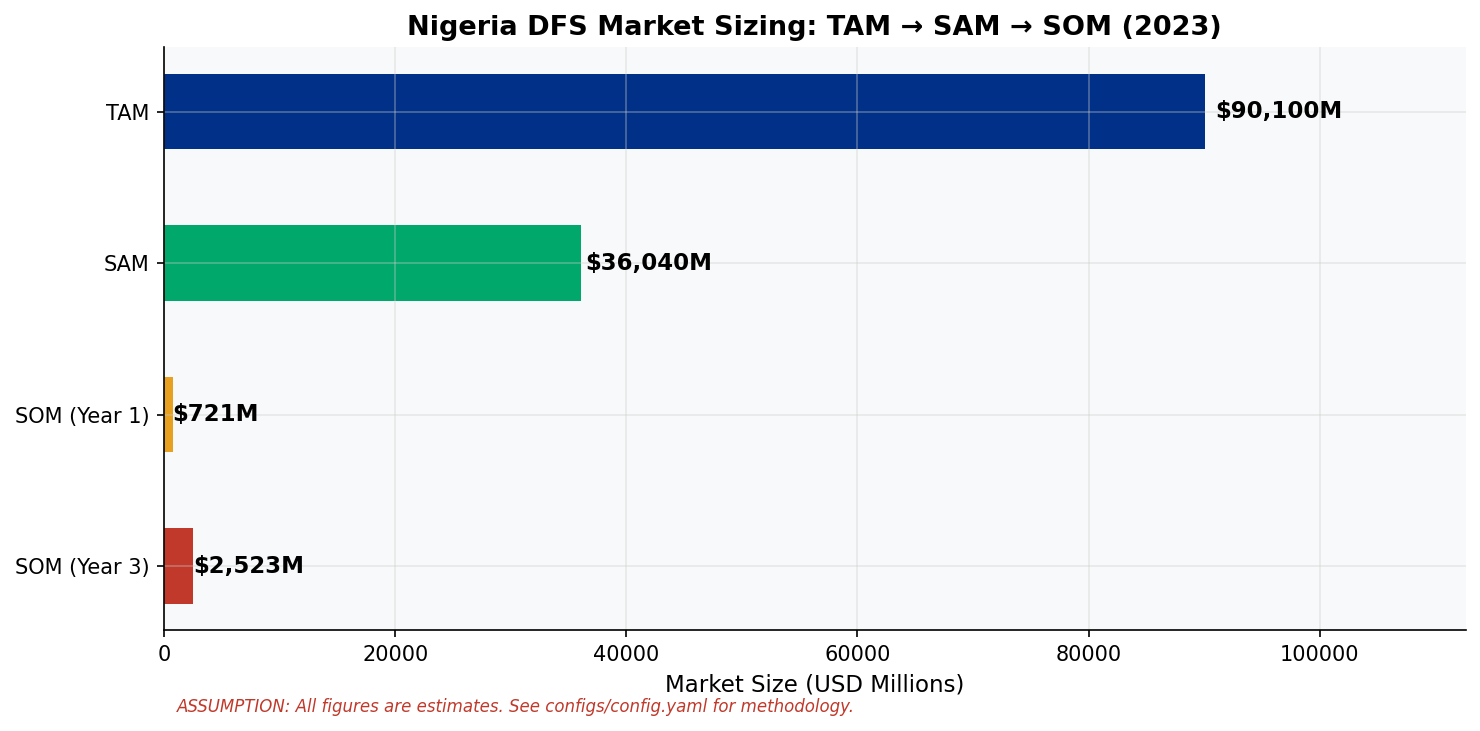

In [5]:
# FIGURE 3 — Market Sizing Funnel
r = compute_tam_sam_som()
fig = plot_market_sizing_funnel(
    r['TAM'].market_size_usd_m, r['SAM'].market_size_usd_m,
    r['SOM_Y1'].market_size_usd_m, r['SOM_Y3'].market_size_usd_m
)
save_figure(fig, "PUB_fig03_market_funnel.png")
plt.show()

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig04_risk_matrix.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\therbo_consulting\nigeria_dfs_analysis\reports\figures\PUB_fig04_risk_matrix.pdf


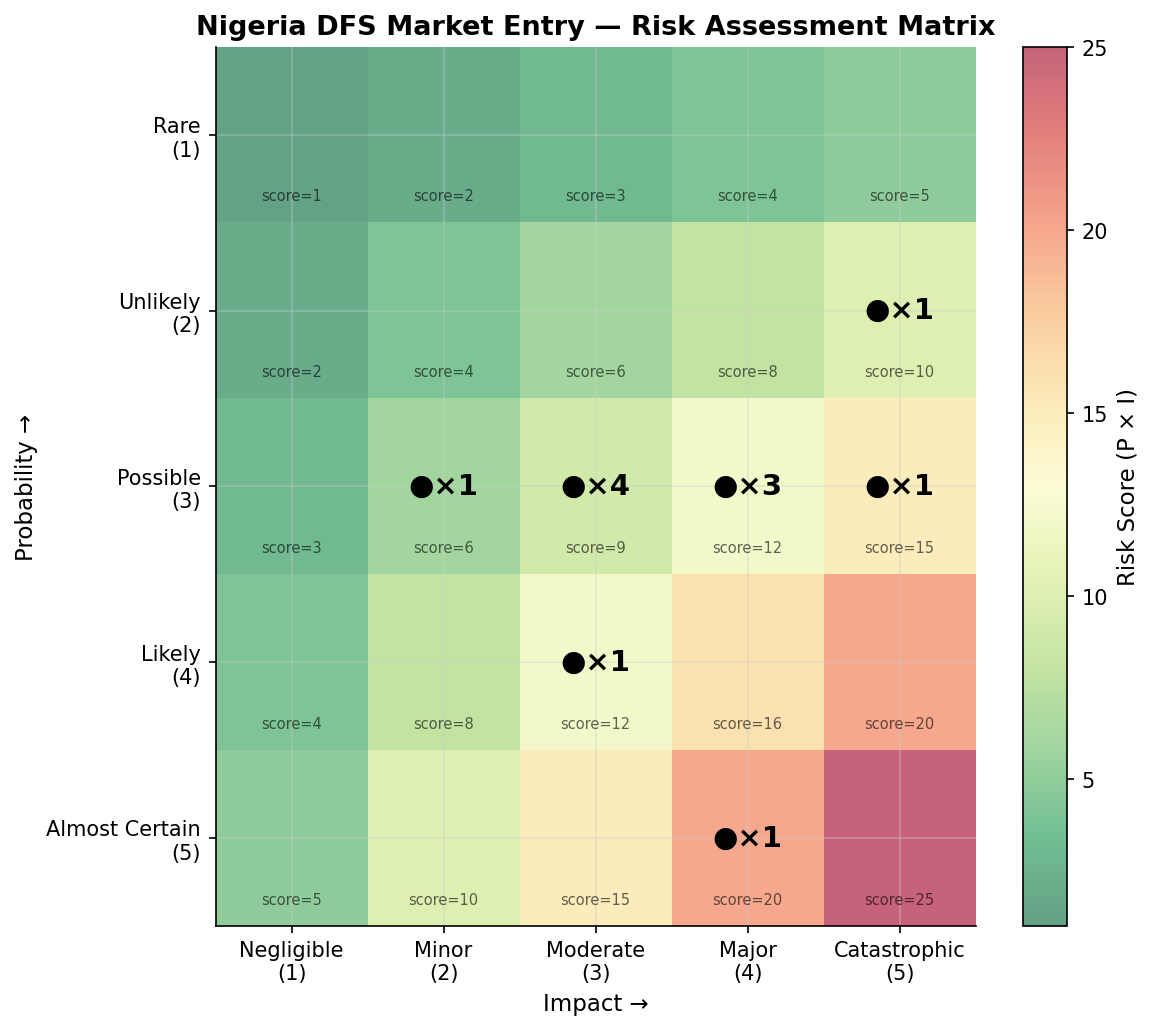

In [7]:
# FIGURE 4 — Risk Matrix
df_risks = build_risk_registry()
fig = plot_risk_matrix(df_risks)
save_figure(fig, "PUB_fig04_risk_matrix.png")
plt.show()

In [8]:
# TABLE 1 — Executive summary statistics
exec_summary = {
    "Metric": [
        "Nigeria Adult Population (2023)",
        "Formally Banked (%)",
        "Financially Excluded (M adults)",
        "Mobile Money Wallets (M, 2023)",
        "NIP Volume (2023, M txns)",
        "NIP Value (2023, ₦ Trillions)",
        "NIP CAGR (2015–2023)",
        "TAM (USD M)",
        "SAM (USD M)",
        "SOM Year 3 (USD M)",
    ],
    "Value": [
        "106 million",
        "45%",
        "~26 million",
        "20 million",
        "8,073 million",
        "₦813 trillion",
        f"{(8073/209)**(1/8)-1:.0%}",
        f"${r['TAM'].market_size_usd_m:,.0f}M",
        f"${r['SAM'].market_size_usd_m:,.0f}M",
        f"${r['SOM_Y3'].market_size_usd_m:,.0f}M",
    ],
    "Source": [
        "World Bank 2023", "EFInA 2023", "EFInA 2023", "CBN 2023",
        "CBN Annual Report 2023", "CBN Annual Report 2023", "Calculated",
        "ASSUMPTION", "ASSUMPTION", "ASSUMPTION",
    ]
}
df_exec = pd.DataFrame(exec_summary)
display(df_exec)
df_exec.to_csv(tables_dir / "executive_summary_stats.csv", index=False)
df_exec.to_csv(paper_tables / "TABLE_01_executive_summary.csv", index=False)
print("\nAll publication tables saved.")

,Metric,Value,Source
0,Nigeria Adult Population (2023),106 million,World Bank 2023
1,Formally Banked (%),45%,EFInA 2023
2,Financially Excluded (M adults),~26 million,EFInA 2023
3,"Mobile Money Wallets (M, 2023)",20 million,CBN 2023
4,"NIP Volume (2023, M txns)","8,073 million",CBN Annual Report 2023
5,"NIP Value (2023, ₦ Trillions)",₦813 trillion,CBN Annual Report 2023
6,NIP CAGR (2015–2023),58%,Calculated
7,TAM (USD M),"$90,100M",ASSUMPTION
8,SAM (USD M),"$36,040M",ASSUMPTION
9,SOM Year 3 (USD M),"$2,523M",ASSUMPTION



All publication tables saved.
